In [1]:
import pandas as pd
df = pd.read_csv('National_Health_and_Aging_Trends_Study__NHATS____Vision_and_Eye_Health_Surveillance_System__VEHSS_.csv')

In [ ]:
# wiek a palenie: "czy palenie ma wpływ na ostrość wzroku"
## filtruje tylko ostrość wzroku do dali
df_vs = df[df["Question"] == "Presenting visual acuity"]
##filtruje tylko palenie
df_vs = df_vs[df_vs["RiskFactor"] == "Smoking"]
## Sprzątanie danych
###usuwanie wierszy gdzie wystepuja pustki
df_vs = df_vs.dropna(subset=["Data_Value", "RiskFactor","RiskFactorResponse", "Response"])
### usunięcie odpowiedzi "Missing presenting aquity"
df_vs = df_vs[df_vs["Response"] != "Missing presenting acuity"]

#####uwzglednienie tylko odpowiedzi normal vision - UWAGA TREZBA ODHASZTAGOWAC JAK MA WYJSC WYKRES KOLUMNOWY!
#df_vs = df_vs[df_vs["Response"] == "Presenting with normal vision"]

print(df_vs.head(5))


    YearStart  YearEnd StateAbbr LocationAbbr LocationDesc GeographicLevel  \
5        2022     2022        US           US     National        National   
7        2022     2022        US           US     National        National   
14       2022     2022        US           US     National        National   
22       2022     2022        US           US     National        National   
31       2022     2022        US           US     National        National   

   DataSource            Topic                Category  \
5       NHATS  Visual Function  Measured Visual Acuity   
7       NHATS  Visual Function  Measured Visual Acuity   
14      NHATS  Visual Function  Measured Visual Acuity   
22      NHATS  Visual Function  Measured Visual Acuity   
31      NHATS  Visual Function  Measured Visual Acuity   

                    Question  ... ResponseID DataValueTypeID      AgeID SexID  \
5   Presenting visual acuity  ...     RVPMOD         CRDPREV  AGE65PLUS  GALL   
7   Presenting visua

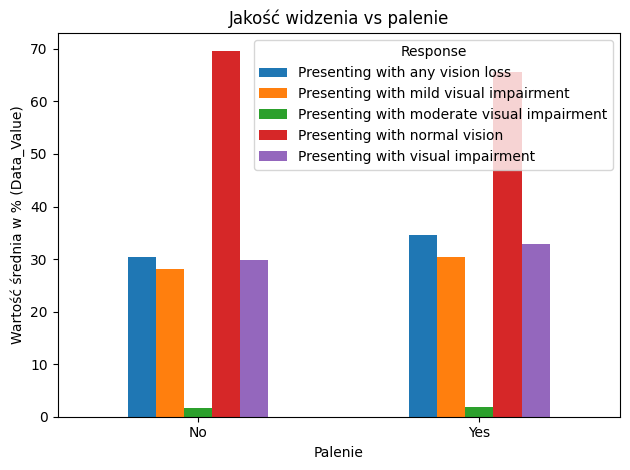

In [ ]:
# tworzenie wykresu
import matplotlib.pyplot as plt
df_vs2 = df_vs
#PONIŻSZE MOŻNA ODHASZTAGOWAC, ALE NIE TRZEBA - WTEDY JEST CZYTELNIEJSZY WYKRES
#df_vs2 = df_vs[df_vs["Response"] == "Presenting with normal vision"]
# zliczanie kombinacji
counts = df_vs2.groupby(["RiskFactorResponse", "Response"])["Data_Value"].mean().unstack()

# wykres
counts.plot(kind="bar")

plt.xlabel("Palenie")
plt.ylabel("Wartość średnia w % (Data_Value)")
plt.title("Jakość widzenia vs palenie")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [52]:
#proba testu chi-kwadrat niezaleznosci
from scipy.stats import chi2_contingency
df_vs3 = df_vs
#ponizsze mozna ohasztagowac, ale nie trezba
df_vs3 = df_vs3[df_vs3["Response"] != "Presenting with any vision loss"]

# 1. Tworzenie tabeli krzyżowej (Crosstab)
# Jeśli Data_Value to procenty, sumujemy je, aby uzyskać proporcje dla grup
contingency_table = pd.crosstab(df_vs3["RiskFactorResponse"], 
                                df_vs3["Response"], 
                                values=df_vs["Data_Value"], 
                                aggfunc="sum").fillna(0)

print("Tabela kontyngencji:")
print(contingency_table)

# 2. Wykonanie testu Chi-kwadrat
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nStatystyka Chi2: {chi2:.4f}")
print(f"Wartość p: {p:.4e}") # format naukowy, bo p może być bardzo małe
print(f"Stopnie swobody: {dof}")

Tabela kontyngencji:
Response            Presenting with mild visual impairment  \
RiskFactorResponse                                           
No                                                  504.39   
Yes                                                 425.28   

Response            Presenting with moderate visual impairment  \
RiskFactorResponse                                               
No                                                       29.53   
Yes                                                       7.11   

Response            Presenting with normal vision  \
RiskFactorResponse                                  
No                                        1252.40   
Yes                                        851.63   

Response            Presenting with visual impairment  
RiskFactorResponse                                     
No                                             537.96  
Yes                                            459.36  

Statystyka Chi2: 20.4417
Wa